In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("food_dataset/complete_products.csv")
data.head(10)

,id,name,brand,ingredients_text,calories,sugar_g,fat_g,saturated_fat_g,protein_g,fiber_g,sodium_mg,health_score,created_at,ingredients_score,product_grade
0,12,Zen Party Mix,Sunridge,"Roasted peanuts (peanuts, peanut or canola oil...",2230.0,3.33,36.67,5.00,16.67,6.7,1.60782,70.23,2026-05-15 23:14:11.089834,71.10,d
1,15,Cinnamon Nut Granola,Grizzlies,"Organic rolled oats, honey, raisins, almonds, ...",1824.0,21.82,18.18,1.82,14.55,9.1,0.02286,78.52,2026-05-15 23:14:11.089834,85.51,b
2,16,Organic Hazelnuts,Grizzlies,Organic raw hazelnuts.,2632.0,3.57,60.71,3.57,14.29,10.7,0.01016,88.11,2026-05-15 23:14:11.089834,85.00,b
3,19,Organic Oat Groats,Pcc,Organic oat groats,1096.0,2.38,5.95,1.19,16.67,9.5,0.02540,95.00,2026-05-15 23:14:11.089834,90.00,a
4,20,Energy Power Mix,Sunridge,"Yogurt raisins, tamari roasted almonds, organi...",1464.0,32.50,17.50,7.50,7.50,5.0,0.28448,44.14,2026-05-15 23:14:11.089834,69.41,d
5,21,Antioxidant Mix - Berries & Chocolate,Sunridge,"Chocolate stars (dehydrated cane juice, sweete...",2092.0,30.00,33.33,6.67,13.33,6.7,0.46482,46.48,2026-05-15 23:14:11.089834,58.59,d
6,22,Organic Quinoa Coconut Granola With Mango,Sunridge,"Organic rolled oats, organic evaporated cane j...",1674.0,27.27,10.91,2.73,10.91,9.1,0.02286,63.91,2026-05-15 23:14:11.089834,75.90,c
7,23,Fire Roasted Hatch Green Chile Almonds,Sunridge,"Dry roasted almonds, hatch green chile seasoni...",2372.0,6.67,50.00,3.33,6.67,10.0,1.27000,65.69,2026-05-15 23:14:11.089834,70.25,d
8,24,Peanut Butter Power Chews,Sunridge,"Peanut butter (dry roasted peanuts, palm oil, ...",1954.0,33.33,20.00,2.22,8.89,4.4,0.19812,52.60,2026-05-15 23:14:11.089834,71.62,c
9,26,Organic Unswt Berry Coconut Granola,New England Naturals,"Organic whole rolled oats, organic expeller pr...",1548.0,5.56,22.22,4.63,12.96,9.3,0.28194,82.64,2026-05-15 23:14:11.089834,82.43,b


In [5]:
X = data[
    [
        "protein_g", "fiber_g", "sugar_g", "saturated_fat_g", "sodium_mg", "ingredients_score"
    ]
]

y = data["health_score"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [10]:
predictions = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 2.00355210526575
R²: 0.9882141510487713


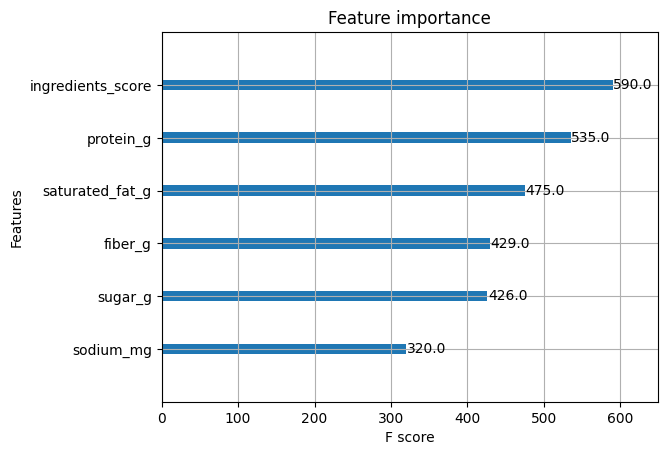

In [14]:
from xgboost import plot_importance

plot_importance(model)
plt.show()